In [1]:
%pwd

'd:\\Tipto\\OmniChef-Nexus\\notebooks'

In [2]:
import os 
os.chdir("../")

In [3]:
%pwd

'd:\\Tipto\\OmniChef-Nexus'

In [4]:
import warnings
warnings.filterwarnings('ignore' , category = FutureWarning)

In [5]:
import torch
from transformers import AutoModel , AutoProcessor
from transformers.image_utils import load_image
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
# load the dataset
IMAGE_DIR = "data/output/images"

from datasets import load_dataset

dataset = load_dataset(
    "imagefolder",
    data_dir = IMAGE_DIR,
    split = 'train'
)
dataset

Resolving data files:   0%|          | 0/15699 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'name', 'minutes', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients', 'recipe_id', 'rating', 'review', 'num_of_ratings', 'markdown_recipe'],
    num_rows: 15698
})

In [7]:
# load the embeddings
from safetensors.torch import load_file

recipe_embeddings = load_file("data/embedding_tensors/all_recipes_embeddings.safetensors")
recipe_embeddings

{'image_embeddings': tensor([[-1.2842,  1.0195,  2.2754,  ..., -2.4297, -0.4502,  0.2676],
         [-1.3857,  0.2522,  1.8154,  ...,  0.2947, -0.4600,  0.7261],
         [-0.1323, -0.9907,  1.1475,  ..., -1.5127, -1.7656, -0.5352],
         ...,
         [-1.0264,  1.6582,  1.0078,  ..., -0.0123, -1.6221,  0.1748],
         [-0.8638, -0.4421, -0.5532,  ..., -0.4114, -1.5869,  0.9663],
         [ 0.3906, -0.1992,  1.4854,  ..., -0.7246, -1.2148, -0.3403]],
        dtype=torch.float16),
 'image_text_embeddings': tensor([[-0.9507,  1.1211,  2.6562,  ..., -2.3281, -0.3948,  0.0395],
         [-1.1504,  0.4902,  2.0195,  ...,  0.7817, -1.3008,  0.6104],
         [-0.1017, -1.1660,  0.9277,  ..., -1.5869, -2.0918, -0.8267],
         ...,
         [-0.7588,  1.2119,  1.5850,  ...,  0.6348, -1.9834, -0.1635],
         [-0.5239, -0.4646, -0.3879,  ..., -0.8237, -1.7998,  0.6162],
         [ 0.2712, -0.6646,  1.5234,  ..., -0.1637, -1.3701, -1.0488]],
        dtype=torch.float16),
 'text_embedd

In [8]:
# move embeddings to gpu
recipe_embeddings = {
    k : v.to(device) for k , v in recipe_embeddings.items()
}

In [9]:
recipe_embeddings

{'image_embeddings': tensor([[-1.2842,  1.0195,  2.2754,  ..., -2.4297, -0.4502,  0.2676],
         [-1.3857,  0.2522,  1.8154,  ...,  0.2947, -0.4600,  0.7261],
         [-0.1323, -0.9907,  1.1475,  ..., -1.5127, -1.7656, -0.5352],
         ...,
         [-1.0264,  1.6582,  1.0078,  ..., -0.0123, -1.6221,  0.1748],
         [-0.8638, -0.4421, -0.5532,  ..., -0.4114, -1.5869,  0.9663],
         [ 0.3906, -0.1992,  1.4854,  ..., -0.7246, -1.2148, -0.3403]],
        device='cuda:0', dtype=torch.float16),
 'image_text_embeddings': tensor([[-0.9507,  1.1211,  2.6562,  ..., -2.3281, -0.3948,  0.0395],
         [-1.1504,  0.4902,  2.0195,  ...,  0.7817, -1.3008,  0.6104],
         [-0.1017, -1.1660,  0.9277,  ..., -1.5869, -2.0918, -0.8267],
         ...,
         [-0.7588,  1.2119,  1.5850,  ...,  0.6348, -1.9834, -0.1635],
         [-0.5239, -0.4646, -0.3879,  ..., -0.8237, -1.7998,  0.6162],
         [ 0.2712, -0.6646,  1.5234,  ..., -0.1637, -1.3701, -1.0488]],
        device='cuda:0', d

In [10]:
# load the embedding model with a specific revision version
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2"
revision = "062ffaa1e3d24a8a50bd6a7ac7b8e54103e1f01d"

embedding_model = AutoModel.from_pretrained(
    model_name,
    revision = revision,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

Loading weights:   0%|          | 0/600 [00:00<?, ?it/s]

In [11]:
# make a helper function to change the model's modality
def prepare_processor(modality , embedding_model):
    """Prepare the model for different modality.

    Args:
        modality (str): can be 'text' , 'image' or 'image_text'
        embedding_model (_type_): embedding model

    Returns:
        _type_: (modality , embedding_model)
    """
    # Set max number of tokens (p_max_length) based on modality
    if modality == "image":
        p_max_length = 2048
    elif modality == "image_text":
        p_max_length = 10240
    elif modality == "text":
        p_max_length = 8192
    embedding_model.processor.p_max_length = p_max_length
    # Image specific settings(only matter if image is present)
    # Sets max number of tiles an image can be split. Each tile consumes 256 tokens.
    embedding_model.processor.max_input_tiles = 6
    # Enables an extra tile with the full image at lower resolution
    embedding_model.processor.use_thumbnail = True
    return modality , embedding_model

In [12]:
from PIL import Image

def _l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)

def match_query_to_embeddings( 
    target_embedding_to_match: torch.Tensor,
    text_query: str = None, 
    image_query: Image.Image = None, 
    top_k: int = 5
):  
    global embedding_model
    
    # identify the modality
    if text_query and image_query:
        modality = "image_text"
    elif text_query:
        modality = "text"
    elif image_query:
        modality = "image"
    else:
        raise ValueError("At least one query (text or image) must be provided.")

    # set model according to the modality
    modality , embedding_model = prepare_processor(
        modality = modality, 
        embedding_model = embedding_model
    )
    
    # do the embedding
    with torch.inference_mode(): 
        if modality == "text":
            query_embedding = embedding_model.encode_queries([text_query])
        elif modality == "image":
            query_embedding = embedding_model.encode_documents(images = [image_query])
        elif modality == "image_text":
            query_embedding = embedding_model.encode_documents(
                texts = [text_query], 
                images = [image_query]
            )

    # make sure all embeddings are in same device
    device = target_embedding_to_match.device
    if not isinstance(query_embedding, torch.Tensor):
        query_embedding = torch.tensor(query_embedding)
    
    # normalize all embeddings
    query_norm = _l2_normalize(query_embedding).to(device)
    target_norm = _l2_normalize(target_embedding_to_match) 
    
    # Calculate Cosine Similarity
    cos_sim = query_norm @ target_norm.T
    cos_sim_flat = cos_sim.flatten()

    # Sort based on highest to lowest similarity score and take top_k
    scores, indices = torch.topk(cos_sim_flat, k = min(top_k, cos_sim_flat.size(0)))
    
    # Extract results
    results = []
    for rank, (idx, score) in enumerate(zip(indices, scores), 1):
        results.append({
            "rank": rank,
            "index": idx.item(),
            "score": score.item()
        })
        
    return results

In [24]:
# example text query
query = "what can I make with egg, seasoning salt, broiler-fryer chicken"

results_without_rerank = match_query_to_embeddings(
    text_query = query,
    target_embedding_to_match = recipe_embeddings['image_text_embeddings'],
    top_k = 10
)
results_without_rerank

[{'rank': 1, 'index': 14168, 'score': 0.388427734375},
 {'rank': 2, 'index': 2160, 'score': 0.381103515625},
 {'rank': 3, 'index': 6128, 'score': 0.357666015625},
 {'rank': 4, 'index': 8194, 'score': 0.3544921875},
 {'rank': 5, 'index': 8324, 'score': 0.349853515625},
 {'rank': 6, 'index': 10608, 'score': 0.349609375},
 {'rank': 7, 'index': 12646, 'score': 0.3447265625},
 {'rank': 8, 'index': 3925, 'score': 0.3388671875},
 {'rank': 9, 'index': 14176, 'score': 0.33642578125},
 {'rank': 10, 'index': 11122, 'score': 0.335693359375}]

In [14]:
import matplotlib.pyplot as plt

def plot_top3_recipes(results, query = query, dataset = dataset ,embedding_type="image_text_embeddings"):
    
    top3 = results[:3]
    top3_indices = [item["index"] for item in top3]
    top3_scores  = [item["score"] for item in top3]
    
    samples = [dataset[i] for i in top3_indices]
    
    plt.figure(figsize=(18, 6))
    
    for i, (sample, score) in enumerate(zip(samples, top3_scores)):
        
        img = sample["image"]
        title = sample["name"]
        
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(
            f"Rank {i+1}\n"
            f"{title}\n"
            f"Score: {score:.4f}",
            fontsize=10
        )

    plt.suptitle(
        f"Query: {query}\nEmbeddings: {embedding_type}",
        fontsize=14
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.90])
    plt.show()

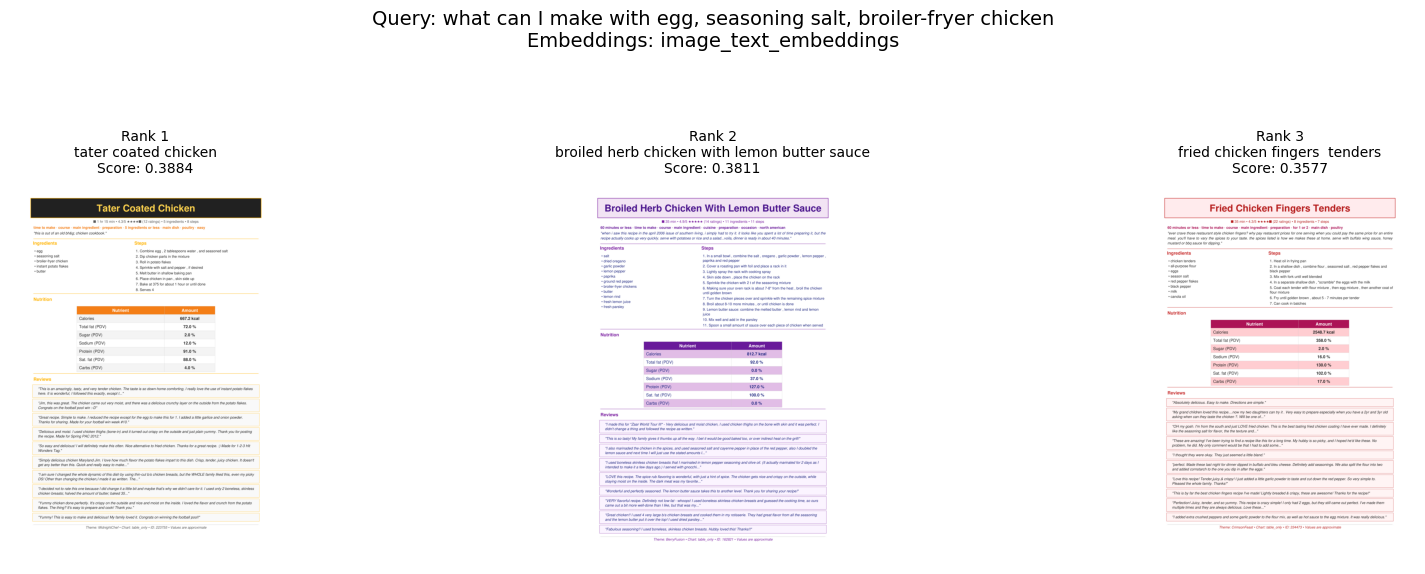

In [25]:
plot_top3_recipes(
    results = results_without_rerank[ : 3]
)

In [16]:
# load the re-rank model
from transformers import AutoModelForSequenceClassification,AutoProcessor

re_rank_model_path = "nvidia/llama-nemotron-rerank-vl-1b-v2"

rerank_model = AutoModelForSequenceClassification.from_pretrained(
    re_rank_model_path,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

Loading weights:   0%|          | 0/601 [00:00<?, ?it/s]

In [17]:
# Build processor kwargs (base settings)
processor_kwargs = {
    "trust_remote_code": True,
    "max_input_tiles": 6,
    "use_thumbnail": True
}

In [18]:
# set rerank max token length based on modality
modality = "image_text"

if modality == "image":
    processor_kwargs['rerank_max_length'] = 2048
elif modality == "text":
    processor_kwargs['rerank_max_length'] = 8192
elif modality == "image_text":
    processor_kwargs['rerank_max_length'] = 10240

In [19]:
# load the processor with modality specific kwargs
processor = AutoProcessor.from_pretrained(
    re_rank_model_path,
    **processor_kwargs
)

In [26]:
# get the data to re-rank
candidate_indices = [res['index'] for res in results_without_rerank]
candidates = [dataset[index] for index in candidate_indices]

In [27]:
# setup question,doc_text and doc_image for the reranker
examples = []
for item in candidates:
    examples.append({
        "question": query,
        "doc_text": item['markdown_recipe'],
        "doc_image": item["image"]
    })

In [28]:
# process the batch
batch_dict = processor.process_queries_documents_crossencoder(examples)
batch_dict = {
    k : v.to(device) if isinstance(v , torch.Tensor) else v 
    for k , v in batch_dict.items()
}

In [29]:
# now re-rank the docs
with torch.inference_mode():
    outputs = rerank_model(**batch_dict , return_dict = True)

In [30]:
outputs.logits

tensor([[-2.1024],
        [-4.4535],
        [-4.9182],
        [-5.1655],
        [-5.1110],
        [-5.4053],
        [-5.0929],
        [-5.5501],
        [-5.2783],
        [-5.4644]], device='cuda:0')

In [ ]:
# now outputs has the logits for top k samples
logits = outputs.logits.squeeze(-1)
logits.shape

torch.Size([10])

In [32]:
logits

tensor([-2.1024, -4.4535, -4.9182, -5.1655, -5.1110, -5.4053, -5.0929, -5.5501,
        -5.2783, -5.4644], device='cuda:0')

In [36]:
probabilities = torch.softmax(logits , dim = 0)
probabilities

tensor([0.6913, 0.0659, 0.0414, 0.0323, 0.0341, 0.0254, 0.0347, 0.0220, 0.0289,
        0.0240], device='cuda:0')

In [45]:
# now re-rank the documents based on logits score
probabilities = torch.softmax(logits , dim = 0)
reranked_list = []
for i, score in enumerate(logits):
    reranked_list.append({
        "index": candidate_indices[i],
        "score": score.item(),
        "softmax_val": probabilities[i].item()
    })

# Sort by the new score (highest first)
reranked_list.sort(key=lambda x: x['score'], reverse=True)

final_output = []
for rank, item in enumerate(reranked_list, 1):
    final_output.append({
        "rank": rank,
        "index": item["index"],
        "score": item["score"],
        "softmax_val": item["softmax_val"]
    })

In [46]:
final_output

[{'rank': 1,
  'index': 14168,
  'score': -2.1024129390716553,
  'softmax_val': 0.6913172006607056},
 {'rank': 2,
  'index': 2160,
  'score': -4.453454971313477,
  'softmax_val': 0.06586167216300964},
 {'rank': 3,
  'index': 6128,
  'score': -4.91821813583374,
  'softmax_val': 0.04137983173131943},
 {'rank': 4,
  'index': 12646,
  'score': -5.092897415161133,
  'softmax_val': 0.03474773094058037},
 {'rank': 5,
  'index': 8324,
  'score': -5.1110053062438965,
  'softmax_val': 0.034124184399843216},
 {'rank': 6,
  'index': 8194,
  'score': -5.165546417236328,
  'softmax_val': 0.03231285884976387},
 {'rank': 7,
  'index': 14176,
  'score': -5.2782745361328125,
  'softmax_val': 0.028868097811937332},
 {'rank': 8,
  'index': 10608,
  'score': -5.405271053314209,
  'softmax_val': 0.025425195693969727},
 {'rank': 9,
  'index': 11122,
  'score': -5.464365005493164,
  'softmax_val': 0.02396625280380249},
 {'rank': 10,
  'index': 3925,
  'score': -5.550104141235352,
  'softmax_val': 0.0219970326

In [47]:
from tabulate import tabulate

def compare_reranking_results(before, after):
    """
    Compares two lists of results and prints a table showing rank shifts.
    """
    # Create a mapping for quick lookup of the 'before' state
    before_map = {item['index']: item for item in before}
    
    comparison_data = []
    
    for item_after in after:
        idx = item_after['index']
        new_rank = item_after['rank']
        new_score = item_after['score']
        
        # Check if the item existed in the 'before' list
        if idx in before_map:
            item_before = before_map[idx]
            old_rank = item_before['rank']
            old_score = item_before['score']
            
            # Calculate shift (positive is good/up, negative is down)
            shift_val = old_rank - new_rank
            if shift_val > 0:
                shift = f"⬆️ +{shift_val}"
            elif shift_val < 0:
                shift = f"⬇️ {shift_val}"
            else:
                shift = "➖ 0"
        else:
            old_rank = "N/A"
            old_score = "N/A"
            shift = "🆕 New"

        comparison_data.append([
            new_rank,
            idx,
            f"{old_score:.4f}" if old_score != "N/A" else "N/A",
            f"{new_score:.4f}",
            f"{old_rank} ➔ {new_rank}",
            shift
        ])

    headers = ["New Rank", "Dataset Index", "Sim Score", "Rerank Logit", "Rank Change", "Shift"]
    print("\n" + "="*80)
    print("                      RETRIEVAL VS. RERANKING COMPARISON")
    print("="*80)
    print(tabulate(comparison_data, headers=headers, tablefmt="fancy_grid"))
    print("="*80 + "\n")

In [48]:
compare_reranking_results(results_without_rerank , final_output)


                      RETRIEVAL VS. RERANKING COMPARISON
╒════════════╤═════════════════╤═════════════╤════════════════╤═══════════════╤═════════╕
│   New Rank │   Dataset Index │   Sim Score │   Rerank Logit │ Rank Change   │ Shift   │
╞════════════╪═════════════════╪═════════════╪════════════════╪═══════════════╪═════════╡
│          1 │           14168 │      0.3884 │        -2.1024 │ 1 ➔ 1         │ ➖ 0    │
├────────────┼─────────────────┼─────────────┼────────────────┼───────────────┼─────────┤
│          2 │            2160 │      0.3811 │        -4.4535 │ 2 ➔ 2         │ ➖ 0    │
├────────────┼─────────────────┼─────────────┼────────────────┼───────────────┼─────────┤
│          3 │            6128 │      0.3577 │        -4.9182 │ 3 ➔ 3         │ ➖ 0    │
├────────────┼─────────────────┼─────────────┼────────────────┼───────────────┼─────────┤
│          4 │           12646 │      0.3447 │        -5.0929 │ 7 ➔ 4         │ ⬆️ +3   │
├────────────┼─────────────────┼─────────────

### Gradio Demo
---

- User wil be able to pass query(text/image/text+image).
- We will show them the retrived recipe images.
- Optionally, user can do re-rank the retrived results.

In [50]:
def rerank_results(
    query_text, 
    query_image, 
    retrieved_results, 
    dataset, 
    rerank_model, 
    rerank_processor, 
    modality="image_text"
):
    """
    Takes initial search results and reranks them using the Cross-Encoder model.
    """
    # Identify the device the model is living on (CUDA or CPU)
    device = next(rerank_model.parameters()).device
    
    # 1. Prepare candidates from the dataset based on retrieved indices
    examples = []
    candidate_indices = [res['index'] for res in retrieved_results]
    
    for idx in candidate_indices:
        item = dataset[idx]
        
        # Prepare the dictionary format required by the Nemotron processor
        example = {"question": query_text if query_text else ""}
        
        if modality == "image":
            example.update({"doc_text": "", "doc_image": item["image"]})
        elif modality == "text":
            example.update({"doc_text": item["name"], "doc_image": ""}) 
        elif modality == "image_text":
            # We use 'name' as the document text context
            example.update({"doc_text": item["name"], "doc_image": item["image"]})
            
        examples.append(example)

    # 2. Process with the Cross-Encoder processor
    # This handles the complex multimodal patching and tokenization
    batch_dict = rerank_processor.process_queries_documents_crossencoder(examples)
    
    # Move tensors to the model's device
    batch_dict = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in batch_dict.items()
    }

    # 3. Run Inference (The "Reasoning" step)
    with torch.no_grad():
        outputs = rerank_model(**batch_dict, return_dict=True)
    
    # 4. Extract Logits
    logits = outputs.logits.squeeze(-1).cpu() 
    
    # 5. Map new scores back to their original dataset indices
    reranked_data = []
    for i, logit_val in enumerate(logits):
        reranked_data.append({
            "index": candidate_indices[i],
            "score": logit_val.item()
        })
    
    # 6. Sort by the new Cross-Encoder score (Descending)
    reranked_data.sort(key=lambda x: x['score'], reverse=True)
    
    # 7. Format into the standard list of dictionaries
    final_results = []
    for rank, item in enumerate(reranked_data, 1):
        final_results.append({
            "rank": rank,
            "index": item["index"],
            "score": item["score"]
        })
        
    return final_results

In [56]:
import gradio as gr

def gradio_app():
    import gradio as gr
    import torch

    def format_gallery(results):
        return [
            (
                dataset[res['index']]['image'],
                f"Rank {res['rank']} | Score: {res['score']:.3f}\n{dataset[res['index']]['name']}"
            )
            for res in results
        ]

    def initial_search(text_query, image_query, top_k):
        results = match_query_to_embeddings(
            text_query=text_query,
            image_query=image_query,
            target_embedding_to_match=recipe_embeddings['image_text_embeddings'],
            top_k=int(top_k)
        )
        return format_gallery(results), results

    def apply_rerank(text_query, image_query, initial_results):
        if not initial_results:
            return None

        reranked = rerank_results(
            query_text=text_query,
            query_image=image_query,
            retrieved_results=initial_results,
            dataset=dataset,
            rerank_model=rerank_model,
            rerank_processor=processor,
            modality="image_text"
        )
        return format_gallery(reranked)

    # ✅ NO theme here
    with gr.Blocks() as demo:
        gr.Markdown("# 🍳 Smart Recipe Search & Reranker")
        gr.Markdown("Search 15k+ recipes using text and/or images.")

        with gr.Row():
            with gr.Column(scale=1):
                query_text = gr.Textbox(label="Text Query")
                query_img = gr.Image(label="Image Query (Optional)", type="pil")
                top_k_slider = gr.Slider(1, 10, value=5, step=1)

                search_btn = gr.Button("🔍 Initial Search")
                rerank_btn = gr.Button("🧠 Apply AI Reranking")

                stored_results = gr.State()

            with gr.Column(scale=2):
                results_gallery = gr.Gallery(columns=3)

        search_btn.click(
            fn=initial_search,
            inputs=[query_text, query_img, top_k_slider],
            outputs=[results_gallery, stored_results]
        )

        rerank_btn.click(
            fn=apply_rerank,
            inputs=[query_text, query_img, stored_results],
            outputs=results_gallery
        )

    return demo

In [57]:
# Launch the app
app = gradio_app()
app.launch(debug=True, theme = gr.themes.Soft())

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.
